In [4]:
import os
import json
from evaluation_function.compare_MIDI import compare_performance_ED
import numpy as np
from typing import Any
from lf_toolkit.evaluation import Result, Params

cwd = os.getcwd()

cwd = os.getcwd()
dir = os.path.dirname(cwd)
reference_path = os.path.join(dir, "data", "referenceMIDI.json")
response_path = os.path.join(dir, "data", "responseMIDI.json")

with open(reference_path) as f1:
    reference = json.load(f1)

with open(response_path) as f2:
    response = json.load(f2)


# Note Alignment techniques

The goal of the note alignment is to find if the student played any missing or extra notes, and which note is missing/extra.

Based on the findings during the project plan phase, Dynamic Time Warping (DTW) is commonly used for alignment. The algorithm can be found in this book (Chpater 3.2 Dynamic Time Warping):
M. Müller, Fundamentals of Music Processing. Cham: Springer International Publishing, 2021, ISBN: 9783030698072. DOI:https://doi.org/10.1007/978-3-030-69808-9.

In general, this DTW algorithm finds an optimal possibly nonlinear alignment between response MIDI sequence to reference MIDI sequence.

Basic approach:
- Evaluating the local cost measure for each pair of elements in the response(X) and reference(Y) sequences. 
- Dynamic programming to find an alignment path between X and Y having minimal overall cost, i.e. DTW distance. The algorithm computes a cumulative distance path, the timestamps of the target MIDI are warped so they perfectly align with the anchor points of the reference MIDI.

However, this basic approach will not correctly handle the missing note case as expected, because it allows a note to match with multiple notes, and each note must be paired. Let's say, there is a note missing in the response, this algorithm tends to match a response note with two reference note, instead of reporting the missing problem.

Another note alignment for music comparison method is based on Edit Distance (ED), see https://www.math.univ-toulouse.fr/~mongeau/music.pdf, where the reference note sequence and the student's response sequence are aligned using dynamic programming. Instead of using a constant replacement cost as in the classic ED algroithm, here absolute pitch difference (measured in MIDI semitones) between two notes is used, so that matched note pairs have zero cost while larger pitch deviations have proportionally higher penalties.

Insertion and deletion operations are represented by a fixed gap penalty, corresponding to extra notes played by the student and missing notes from the reference sequence, respectively. The gap penalty is empirically set to 6. This value is chosen to encourage the alignment algorithm to interpret most pitch deviations as replacement (wrong pitches) rather than decomposing them into separate insertion and deletion operations. Such behaviour is more consistent with common music teaching practice, where a note played at the correct temporal position but with an incorrect pitch is typically regarded as a wrong note instead of a missing note accompanied by an extra note.

After constructing the accumulated cost matrix, backtracking is performed to recover the optimal alignment path. Each aligned pair is classified as one of four operation types: match, replacement, missing, or extra. These structured operations are subsequently used to generate formative feedback for the learner.

Proportional tolerances are used instead of fixed absolute thresholds, because a fixed tolerance (e.g. +/-0.5 s) is unfair: it is too tolerant for long notes and overly strict for short notes

In [5]:
result = compare_performance_ED(response, reference)
print(result.feedback_message)

Overview: 
Timing: your overall tempo is within an acceptable range. Good job! The timing is about 3% behind the reference in general while notes are held about 10% longer than the reference.
There is 1 note played with the wrong pitch.
There is 1 note you missed from the reference.
There are no extra notes. Good job!

Detail: 
Note 5 (pitch 67) is missing in your performance.
Note 2: wrong pitch — expected 62, played 63 (1 semitone(s) off).
Note 4: duration is 0.15s longer than the reference (i.e. 30% off) after accounting for the overall duration trend 


### Visualisation

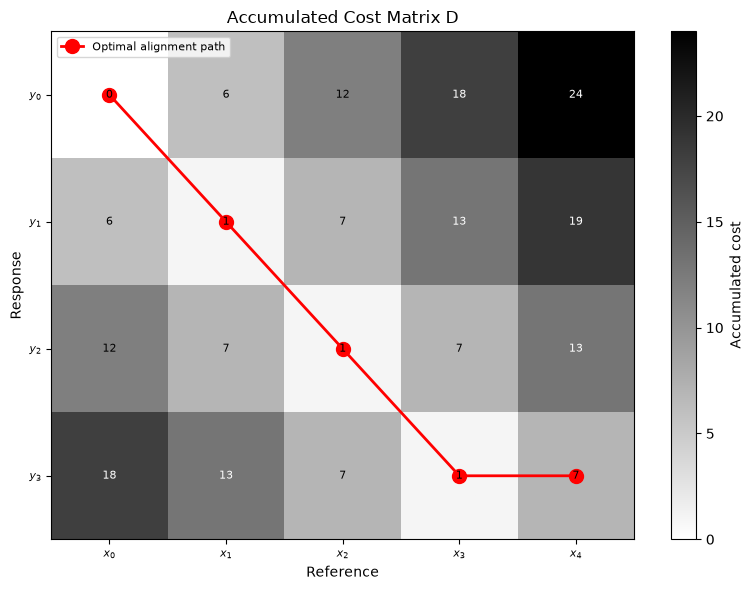

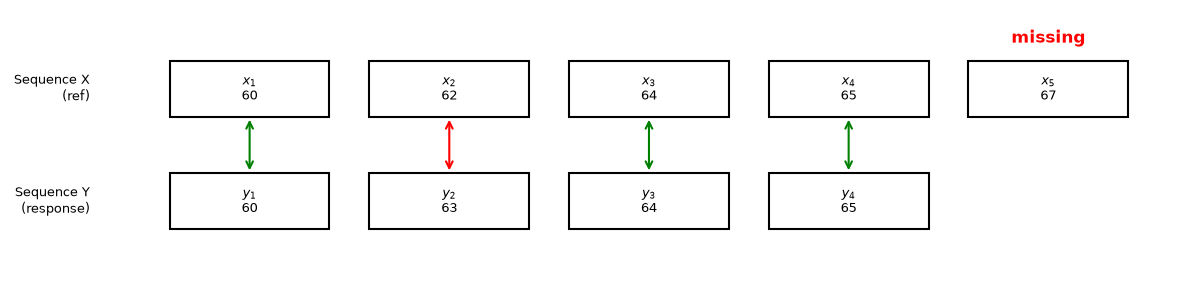

In [ ]:
# use ChatGPT to help with the code for the cost matrix and alignment arrows, wrote the code myself
import matplotlib.pyplot as plt

def plot_cost_matrix(D, operations, response_notes, ref_notes):
    fig, ax = plt.subplots(figsize=(8, 6))
    D_display = D[1:, 1:]
    im = ax.imshow(D_display, origin="upper", aspect="auto", cmap="gray_r")
    plt.colorbar(im, ax=ax, label="Accumulated cost")
    for i in range(D_display.shape[0]):
        for j in range(D_display.shape[1]):
            val = D_display[i, j]
            ax.text(j, i, f"{val:.0f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if val > D_display.max() * 0.5 else "black")
    path_rows, path_cols = [], []
    for op in operations:
        if op["type"] in ("match", "replacement"):
            path_rows.append(op["response_idx"])
            path_cols.append(op["reference_idx"])
        elif op["type"] == "extra":
            path_rows.append(op["response_idx"])
            path_cols.append(path_cols[-1] if path_cols else 0)
        elif op["type"] == "missing":
            path_rows.append(path_rows[-1] if path_rows else 0)
            path_cols.append(op["reference_idx"])
    ax.plot(path_cols, path_rows, "ro-", markersize=10, linewidth=2,
            label="Optimal alignment path")
    ref_labels = [f"$x_{j}$" for j in range(len(ref_notes))]
    response_labels = [f"$y_{i}$" for i in range(len(response_notes))]
    ax.set_xticks(range(len(ref_labels)))
    ax.set_xticklabels(ref_labels, fontsize=8)
    ax.set_yticks(range(len(response_labels)))
    ax.set_yticklabels(response_labels, fontsize=8)
    ax.set_xlabel("Reference")
    ax.set_ylabel("Response")
    ax.set_title("Accumulated Cost Matrix D")
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_alignment_arrows(operations, response_notes, ref_notes):
    fig, ax = plt.subplots(figsize=(12, 3))
    N = len(response_notes)
    M = len(ref_notes)
    for j, note in enumerate(ref_notes):
        ax.add_patch(plt.Rectangle((j - 0.4, 0.75), 0.8, 0.5,
                                   fill=False, edgecolor="black", linewidth=1.5))
        ax.text(j, 1.0, f"$x_{{{j+1}}}$\n{note['pitch']}",
                ha="center", va="center", fontsize=9)
    for i, note in enumerate(response_notes):
        ax.add_patch(plt.Rectangle((i - 0.4, -0.25), 0.8, 0.5,
                                   fill=False, edgecolor="black", linewidth=1.5))
        ax.text(i, 0.0, f"$y_{{{i+1}}}$\n{note['pitch']}",
                ha="center", va="center", fontsize=9)
    for op in operations:
        if op["type"] in ("match", "replacement"):
            colour = "green" if op["type"] == "match" else "red"
            ax.annotate("",
                xy=(op["response_idx"], 0.25),
                xytext=(op["reference_idx"], 0.75),
                arrowprops=dict(arrowstyle="<->", color=colour,
                                lw=1.5, mutation_scale=12),
            )
        elif op["type"] == "missing":
            j = op["reference_idx"]
            ax.text(j, 1.45, "missing", ha="center", va="center",
                    fontsize=12, color="red", fontweight="bold")
        elif op["type"] == "extra":
            i = op["response_idx"]
            ax.text(i, -0.45, "extra", ha="center", va="center",
                    fontsize=12, color="red", fontweight="bold")
    ax.text(-0.8, 1.0, "Sequence X\n(ref)", ha="right", va="center", fontsize=9)
    ax.text(-0.8, 0.0, "Sequence Y\n(response)", ha="right", va="center", fontsize=9)
    ax.set_xlim(-1.2, max(N, M) - 0.4)
    ax.set_ylim(-0.7, 1.7)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

result = compare_performance_ED(response, reference)
plot_cost_matrix(result.D, result.operations, response["notes"], reference["notes"])
plot_alignment_arrows(result.operations, response["notes"], reference["notes"])

### Summary

Step 0: Normalise the start times
- Adjust the start time of the first note to t=0 for both the reference and the response MIDI. This action will help eliminate the time gap between student start recording their practice and start playing the first note (if the gap exists).

Step 1: Align notes using edit distance
- The purpose of note alignment here is to identify if there is any missing/extra notes. Unlike standard DTW where off-diagonal moves has no cost and every note must be aligned to another, the Edit-distance approach allows a note to be explicitly left unaligned at the cost of gap_penalty, i.e. allows for insertions (extra notes) and deletions (missing notes). Each aligned pair or unmatched element is classified into one of the four operation types according to the moving direction during backtracking:
    - diagonal = match (identical pitch)/replacement (wrong pitch)
    - vertical = extra (additional note played)
    - horizontal = missing (note not played)
 
Step 2: Estimate the overall tempo trend
- It is common for students to play at a slower tempo by setting the metronome to a slower pace during practice. Then after becoming more and more familiar with it, they may speed up unconsciously especially for the easier parts. Therefore, to avoid prompting the tempo problem for every single note in these cases, the global drift problem must be separated from local deviations. 
- `estimate_global_timing` fits a linear regression over all matched note pairs: response_start ≈ scale × ref_start + offset, where scale represents the student's overall tempo relative to the reference (greater than 1.0 indicates playing slower; less than 1.0 indicates playing faster), and offset captures any constant time shift.
- `estimate_global_duration_scale` fits a least-squares regression, this regression line passes through the origin because note duration has no meaningful constant offset term: response_duration ≈ duration_scale × ref_duration, where duration_scale represents the general holding time for notes relative to the reference (greater than 1.0 indicates longer holding; less than 1.0 indicates shorter holding time)
- To ensure the fitting method is statistically and musically meaningful, if the amount of matched pairs available is smaller than three, the functions will assume there is no global tempo trend. 
- The slow/fast decision mainly depends on the scale for timing.
    
Step 3: note-level evaluation for matched pairs

Pitch:
— A note is considered correct if and only if the pitch matches exactly (pitch_diff == 0). 
- The absolute semitone difference is recorded for feedback.
Timing:
— The expected start time is predicted from the global trend line, then the relative difference in start time is calculated by ∣response_start − predicted_start∣ / inter-onset interval (IOI) of the reference note, 
a note is considered correct if this relative difference is within a threshold.
- In the feedback, the amount of difference will be reported instead of directly indicate the correctness, so that the students will not be discourage to include their expressiveness in certain parts of the practice.
- The first note (ref_idx == 0) is always marked as timing-correct, since normalisation in Step 0 guarantees both sequences start at t = 0.
Duration 
— The expected duration is predicted from the global duration scale, then the relative difference in duration is calculated by ∣response_duration − predicted_duration∣ / ref_duration, a note is considered correct if this relative difference is within a threshold.

Step 4: Compute summary statistics
- Summary counts, including total notes missing, extra, wrong pitch, wrong timing, and wrong duration, as well as boolean flags indicating whether all paired notes are correct on each dimension. The global trend parameters (timing_scale, timing_offset, duration_scale) are also included. 

Step 5: Generate the human-readable feedback messages from those statistics and note-level feedback
- Overview provides a summary of the student's overall performance:
    - Tempo judgement based on timing_scale: explicitly states whether the overall tempo is acceptable, too slow, or too fast, along with the duration_scale as supplementary context
    - Total count of pitch errors, missing notes, and extra notes
- Detail provides actionable, note-level feedback for each issue identified:
    - Missing/extra notes: identifies the specific note and pitch
    - Pitch errors: states the expected and played pitch, and the semitone difference
    - Local timing anomalies: reports the absolute and relative deviation after the global trend has been removed
    - Local duration anomalies: reports the deviation direction and magnitude after the global duration scale has been removed